<div style="background-color: #c62cce ; padding: 20px; border-radius: 10px;">

<h1 style="color: black; text-align: center;">
    Projet ML : Diabetes Patient Readmission Prediction Using Machine Learning 🩺
</h1>

<h3 style="color: black; text-align: center;">
    Notebook Pre-processing
</h3>

<h5 style="color: black; text-align: center;">
    Ovia Chanemouganandam & Sandrine Daniel – DIA 4
</h5>

</div>


In [175]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from IPython.display import Image
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import os
from scipy.stats import chi2_contingency
import matplotlib.cm as cm


# <font color='#c62cce'> <b>1. Import dataset  </b></font>

In [176]:
df =pd.read_csv('data/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Number of columns and rows

In [177]:
print("Number of columns:", df.shape[1])
print("Number of rows:", df.shape[0])

Number of columns: 50
Number of rows: 101766


# <font color='#c62cce'> <b>2. Variable definition  </b></font>

<div style="background-color: #f3d0f5ff ; color: black ; padding: 20px; border-radius: 10px;">
The dataset contains information about patients and their medical history. The target variable is **`readmitted`**, which indicates whether a patient was readmitted to the hospital. The dataset has the following columns:

| Feature | Type | Description |
|---------|------|-------------|
| `encounter_id` | Numeric / ID | Unique identifier for an encounter |
| `patient_id` | Numeric / ID | Unique identifier for each patient |
| `race` | Categorical | 	Values: Caucasian, Asian, African American, Hispanic, and other |
| `admission_type` | Categorical | Type of hospital admission (e.g., Emergency, Elective) |
| `admission_source_id` | Categorical | Integer identifier corresponding to 21 distinct values, for example, physician referral, emergency room, and transfer from a hospital|
| `discharge_disposition` | Categorical | How the patient was discharged (e.g., home, transferred) |
| `weight` | Categorical | Weight in pounds |
| `age` | Numeric | Age of the patient in years |
| `gender` | Categorical | Gender of the patient (Male/Female) |
| `num_lab_procedures` | Numeric | Number of lab tests performed during the stay |
| `num_medications` | Numeric | Number of medications prescribed during the stay |
| `time_in_hospital` | Numeric | Number of days spent in the hospital |
| `payer_code` |  Categorical | Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay|
| `Medical_specialty`| Categorical | Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct value|
| `diag_1` | Categorical | Primary diagnosis code |
| `diag_2` | Categorical | Secondary diagnosis code |
| `diag_3` | Categorical | Tertiary diagnosis code |
| `num_procedures` | Numeric | Number of procedures performed during the stay |
| `num_outpatient` | Numeric | Number of outpatient visits in the past year |
| `num_emergency` | Numeric | Number of emergency visits in the past year |
| `number_diagnoses` | Numeric | Number of diagnoses entered to the system|
| `max_glu_serum`| Categorical | Indicates the range of the result or if the test was not taken. Values: >200, >300, normal, and none if not measured |
| `A1Cresult` | Categorical | Indicates the range of the result or if the test was not taken. Values: >8 if the result was greater than 8%, >7 if the result was greater than 7% but less than 8%, normal if the result was less than 7%, and none if not measured|
| `For the 23 columns ex: metformin to -> metformin - pioglitazone`  | Categorical | The feature indicates whether the drug was prescribed or there was a change in the dosage |
| `num_inpatient` | Numeric | Number of prior inpatient visits in the past year |
| `change`| Categorical | Indicates if there was a change in diabetic medications (either dosage or generic name). Values: change and no change |
| `diabetesMed` | Categorical | Indicates if there was any diabetic medication prescribed. Values: yes and no |
| `readmitted` | Categorical | Target variable: 
  - `0` = Not readmitted  
  - `1` = Readmitted in less than 30 days  
  - `2` = Readmitted after 30 days or more |





In [178]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

# <font color='#c62cce'> <b>3. Handling missing values and duplicates</b></font>

### **a) Missing values**

In [179]:
print("Number of missing values per column:")
print(df.isna().sum())

Number of missing values per column:
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride

During the visualization of the dataset we noticed that some columns had '?' instead of NaN, we will now replace them with proper missing values

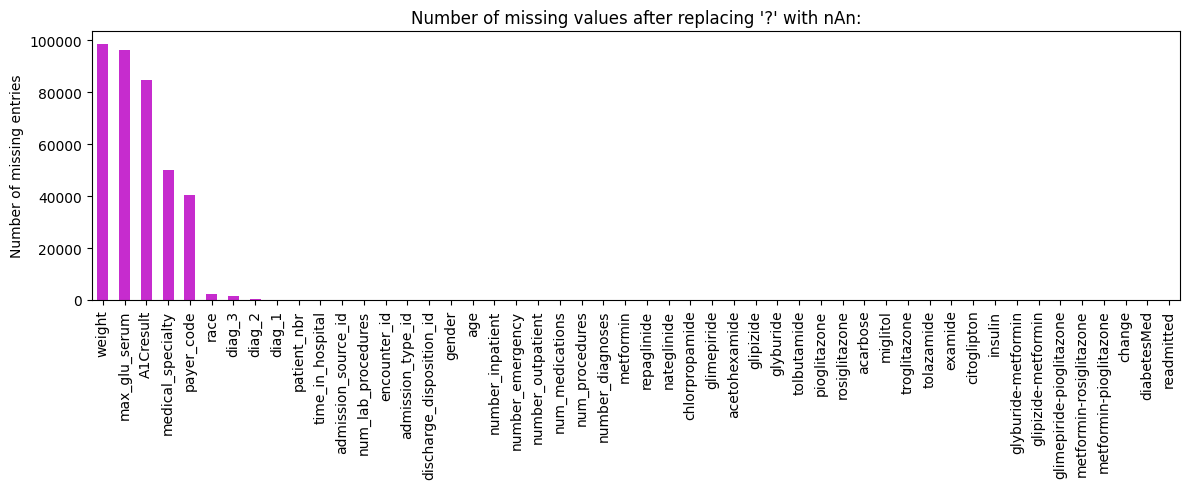

In [180]:

df.replace('?', np.nan, inplace=True)
missing_counts = df.isna().sum().sort_values(ascending=False) # Count missing values per column and sort

plt.figure(figsize=(12, 5)) # Plotting
missing_counts.plot(kind="bar", color="#c62cce")
plt.title("Number of missing values after replacing '?' with nAn:")
plt.ylabel("Number of missing entries")
plt.tight_layout()
plt.show()

The colulmns 'weight', 'payer_code', 'medical_specialty' have more than 50% of missing values, we will therefore drop these columns

In [181]:
df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True) # drop columns with too many missing values

After visualizing our csv we noticed that the gender column has 3 unique values : female, male and unknown/invalid. 
Let's drop the unknown/invalid rows 

In [182]:
df["gender"] = df["gender"].replace({"Unknown/Invalid":np.nan})
df = df.dropna(subset=["gender"])

Let's delete the missing values of these columns : 'diag1','diag2','diag3','race' (the number of these missing values is really inferior to the number of lines)

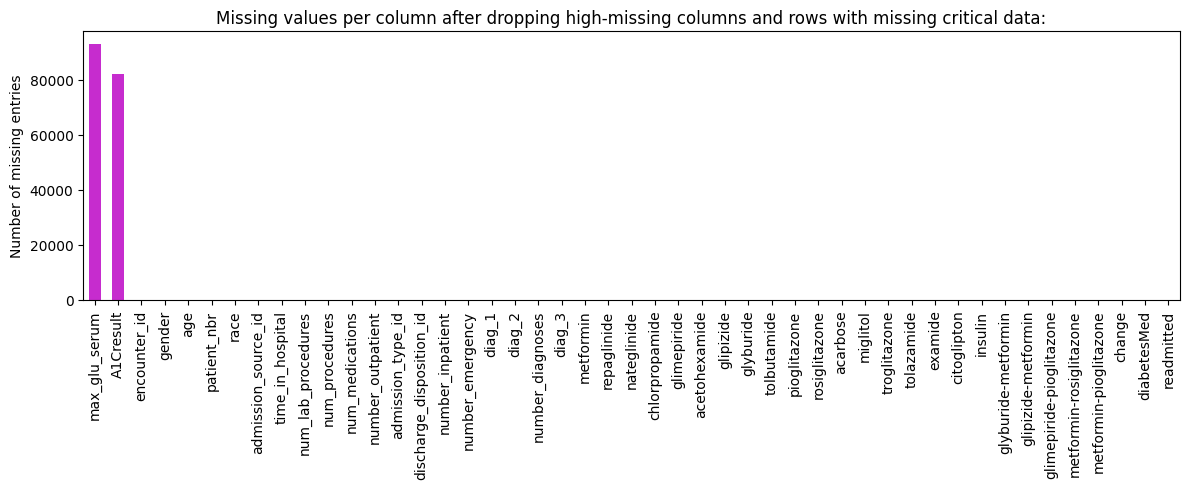

In [183]:
df=df.dropna(subset=['diag_1','diag_2','diag_3','race']) # drop rows with missing critical data

missing_counts = df.isna().sum().sort_values(ascending=False) # Recount missing values per column

plt.figure(figsize=(12, 5)) # Plotting
missing_counts.plot(kind="bar", color="#c62cce")
plt.title("Missing values per column after dropping high-missing columns and rows with missing critical data:")
plt.ylabel("Number of missing entries")
plt.tight_layout()
plt.show()

In the csv, the columns "max_glu_serum" and "A1Cresult" have mostly "None" values that the notebook considers as Nan (they aren't, the test was not taken)

Let's fix this issue 

In [184]:
df["max_glu_serum"] = df["max_glu_serum"].fillna("Test not taken") # fill fake missing values with "Test not taken"
df["A1Cresult"] = df["A1Cresult"].fillna("Test not taken")
print(df.isna().sum()) 

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol  

In [185]:
print("Number of columns after cleaning:", df.shape[1]) # decrease due to column drops
print("Number of rows after cleaning:", df.shape[0]) # slight decrease due to row drops

Number of columns after cleaning: 47
Number of rows after cleaning: 98052


### **b) Duplicates**

In [186]:
print(df.duplicated().sum())
print(df.shape)

0
(98052, 47)


# <font color='#c62cce'> <b>4. Data description and balance</b></font>

In [187]:
df.describe(include='object') #For categorial variables


,race,gender,age,diag_1,diag_2,diag_3,max_glu_serum,A1Cresult,metformin,repaglinide,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,98052,98052,98052,98052,98052,98052,98052,98052,98052,98052,...,98052,98052,98052,98052,98052,98052,98052,98052,98052,98052
unique,5,2,10,713,740,786,4,4,4,4,...,1,4,4,2,2,1,2,2,2,3
top,Caucasian,Female,[70-80),428,428,250,Test not taken,Test not taken,No,No,...,No,No,No,No,No,No,No,No,Yes,NO
freq,75079,52833,25305,6730,6517,11208,92844,81859,78807,96529,...,98052,45942,97383,98039,98051,98052,98051,52774,75350,52337


In [188]:
df.describe() #for numerical variables

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,9.805200e+04,9.805200e+04,98052.000000,98052.000000,98052.000000,98052.000000,98052.000000,98052.000000,98052.000000,98052.000000,98052.000000,98052.000000,98052.000000
mean,1.658301e+08,5.484745e+07,2.025803,3.753396,5.776741,4.422011,43.148462,1.350712,16.119590,0.376382,0.202464,0.646871,7.512096
std,1.024325e+08,3.866167e+07,1.450121,5.309412,4.071632,2.993070,19.711757,1.708475,8.108496,1.283365,0.942897,1.271025,1.832472
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000
25%,8.528559e+07,2.350234e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,11.000000,0.000000,0.000000,0.000000,6.000000
50%,1.533025e+08,4.687610e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.305018e+08,8.800306e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### **Now we check the data balance**

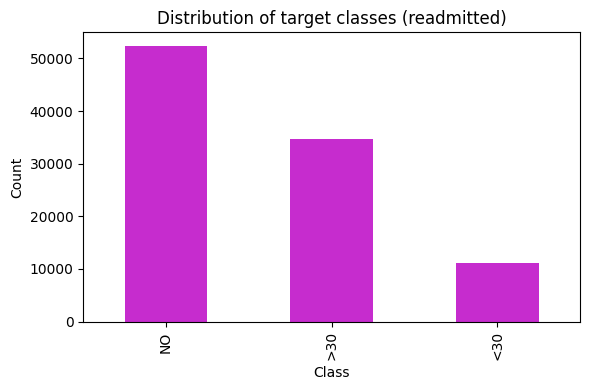

In [189]:
plt.figure(figsize=(6, 4))
df["readmitted"].value_counts().plot(kind="bar", color="#c62cce") # class balance
plt.title("Distribution of target classes (readmitted)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# <font color='#c62cce'> <b>5. Correlation analysis</b></font>

### **a) Pearson correlation for numerical variables**

/tmp/ipykernel_8465/3624664663.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pink_palette = cm.get_cmap('PuRd', 20)


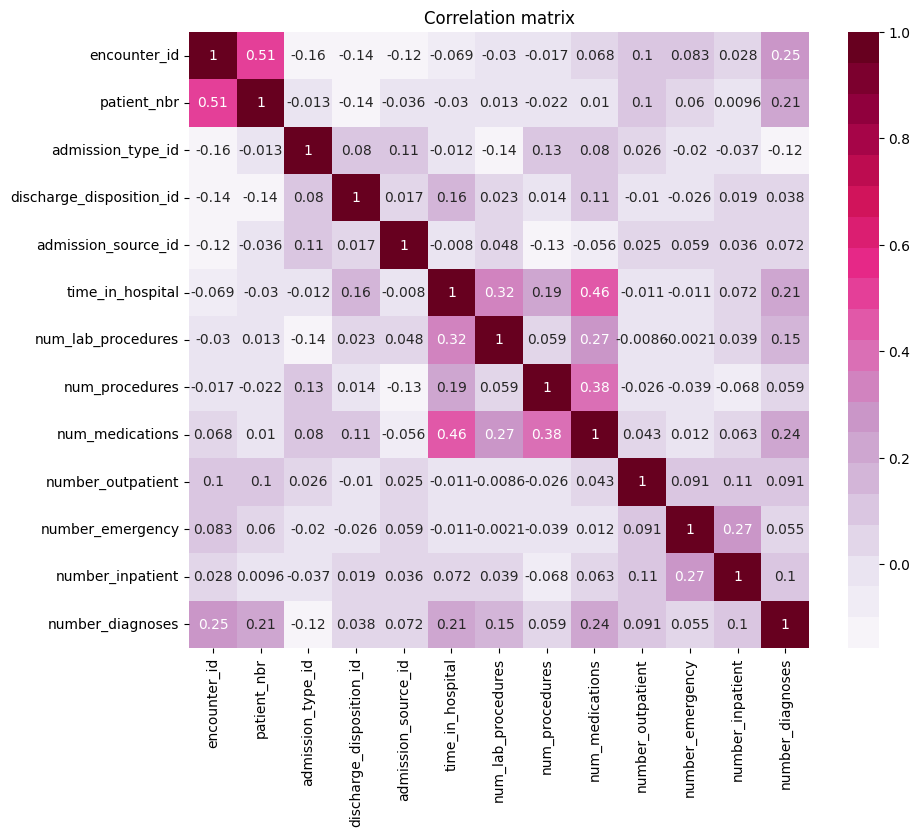

In [190]:
plt.figure(figsize=(10,8))
pink_palette = cm.get_cmap('PuRd', 20) 
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=pink_palette) # correlation matrix for numerical features
plt.title("Correlation matrix")
plt.show()

The correlation matrix was computed only for numerical variables, since correlation coefficients are meaningful only for quantitative data. 

Most numerical variables are weakly correlated, indicating low redundancy.

A few moderate correlations exist between time_in_hospital, num_medications, and num_lab_procedures, which is medically coherent. Because, Longer hospital stays are associated with more lab tests and medications, and patients with more emergency visits tend to have slightly more inpatient admissions.

Identifiers such as encounter_id and patient_nbr should be dropped, as they do not carry useful information for prediction.

### **b) Cramér’s V**

We chose Cramér’s V because our dataset contains mostly nominal categorical variables, and we needed a reliable way to measure their association with the target.

- The Chi-Square test alone is not suitable for comparison, because its value depends on sample size and the number of categories.

- Cramér’s V is a normalized version of Chi-Square (0–1), making the strength of association easy to interpret and comparable across features.

In [191]:
def cramers_v(x, y):
    """
    Cramér's V between two categorical pandas Series x and y.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # correction de biais
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2corr / denom)

target = "readmitted"

# categorical columns excluding the target
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols = [c for c in cat_cols if c != target]

cramer_with_target = {}

for col in cat_cols:
    # we ignore columns with only one unique value or all NaNs
    if df[col].nunique() > 1 and df[col].notna().sum() > 0:
        cramer_with_target[col] = cramers_v(df[col], df[target])

# we transform the dictionary into a pandas Series for easier plotting
cramer_series = pd.Series(cramer_with_target).sort_values(ascending=False)



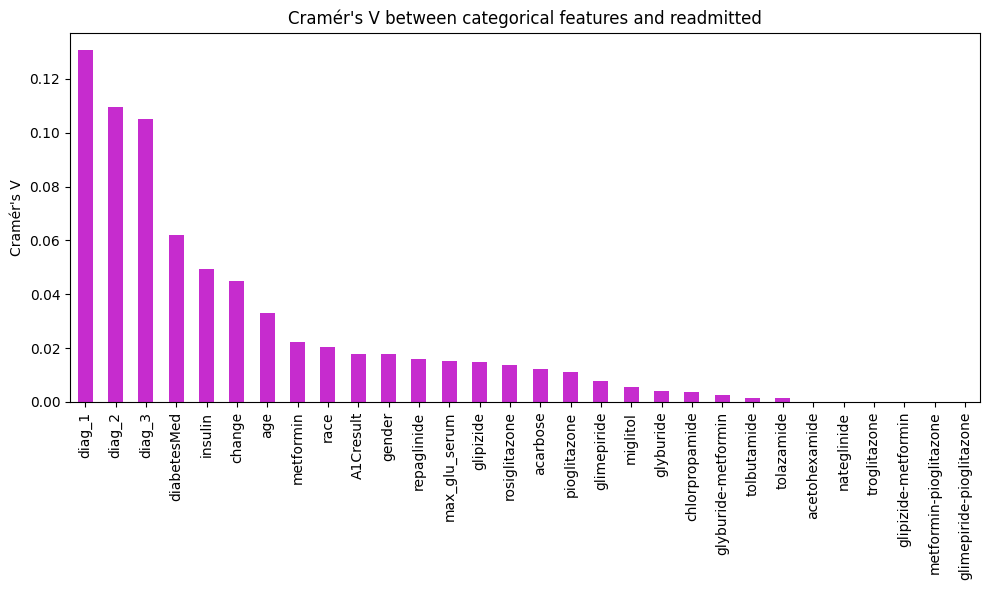

In [192]:
plt.figure(figsize=(10, 6))
cramer_series.plot(kind="bar", color="#c62cce") # cramer's V bars
plt.title("Cramér's V between categorical features and readmitted") 
plt.ylabel("Cramér's V")
plt.tight_layout()
plt.show()

The plot shows the association between each categorical feature and the target readmitted. As expected, the three diagnosis columns (diag_1, diag_2, diag_3) have the highest Cramér’s V values. This is medically logical: a patient’s primary and secondary diagnoses are strong indicators of their risk of being readmitted.

Treatment-related features such as insulin, diabetesMed, and change also show moderate associations. This makes sense clinically, because changes in medication or insulin usage often reflect unstable glucose control or recent complications.

Other features like age, race, and gender show weaker associations, indicating that demographic factors are less predictive of readmission in this dataset. Many individual drug columns have very low values, suggesting they contribute little and may be removed during feature selection.

Overall, the results highlight that diagnoses and diabetes management behaviors are the most informative predictors of readmission.

# <font color='#c62cce'> <b>6. Visualizations</b></font>

### **Age distribution | Most common primary diagnoses (diag_1) | Insulin usage vs readmission**

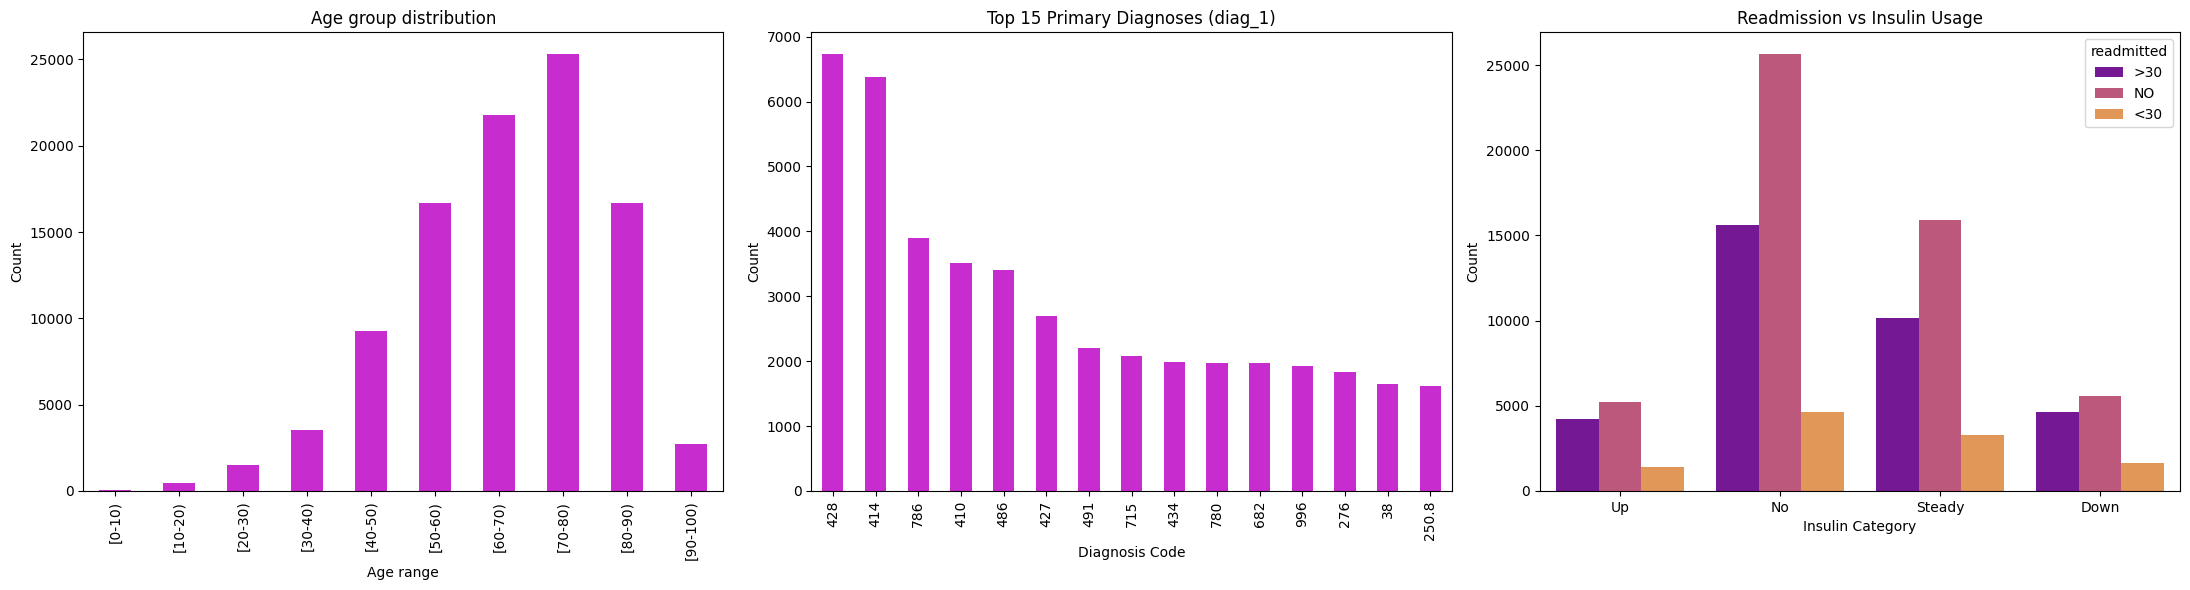

In [193]:
plt.figure(figsize=(22, 6))
# 1. Age distribution

plt.subplot(1, 3, 1)
df['age'].value_counts().sort_index().plot(kind='bar', color="#c62cce")
plt.title("Age group distribution")
plt.xlabel("Age range")
plt.ylabel("Count")


# 2. Most common primary diagnoses (diag_1)

plt.subplot(1, 3, 2)
df['diag_1'].value_counts().head(15).plot(kind='bar', color="#c62cce")
plt.title("Top 15 Primary Diagnoses (diag_1)")
plt.xlabel("Diagnosis Code")
plt.ylabel("Count")


# 3. Insulin usage vs readmission

plt.subplot(1, 3, 3)
sns.countplot(data=df, x="insulin", hue="readmitted", palette="plasma")
plt.title("Readmission vs Insulin Usage")
plt.xlabel("Insulin Category")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### **Exploratory Insights from Age, Diagnoses, and Insulin Usage**

The age distribution shows that most patients fall between 50–80 years old, which aligns with the typical age range for type 2 diabetes and its complications. Younger patients are much less represented in the dataset.

The bar plot of the most frequent primary diagnoses (diag_1) indicates that several chronic conditions appear most often. These are medically consistent with common causes of diabetes-related hospitalizations.

Finally, the readmission rates across insulin usage categories reveal that patients with No or Steady insulin patterns represent the largest groups. The distribution suggests that insulin treatment behavior may have some relationship with readmission outcomes, which supports our earlier Cramér’s V findings showing a moderate association between insulin usage and the target variable.

# <font color='#c62cce'> <b>7. Outlier analysis and droping unnecassary columns</b></font>


#### **We do not perform an outlier analysis because most features are categorical, and the others are medical measures (e.g., glucose, BMI) whose extreme values may represent real medical conditions rather than data errors.**


#### **Then we drop unnecessary  columns** 

In [194]:
df.drop(columns=["encounter_id","patient_nbr"], inplace=True)
df.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [195]:
df = df.drop(columns=["examide", "citoglipton"]) #very low chramer's V with target


# <font color='#c62cce'> <b>8. Encoding categorical columns </b></font>

In [196]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)


Index(['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum',
       'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


##### **Based on the unique values we will choose between binary encoding and one-hot encoding**

In [197]:
cols = ['max_glu_serum',
       'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

for col in cols:
    print(f"--- {col} ---")
    print(df[col].unique(), "\n")


--- max_glu_serum ---
['Test not taken' '>300' 'Norm' '>200'] 

--- A1Cresult ---
['Test not taken' '>7' '>8' 'Norm'] 

--- metformin ---
['No' 'Steady' 'Up' 'Down'] 

--- repaglinide ---
['No' 'Up' 'Steady' 'Down'] 

--- nateglinide ---
['No' 'Steady' 'Down' 'Up'] 

--- chlorpropamide ---
['No' 'Steady' 'Down' 'Up'] 

--- glimepiride ---
['No' 'Steady' 'Down' 'Up'] 

--- acetohexamide ---
['No' 'Steady'] 

--- glipizide ---
['No' 'Steady' 'Up' 'Down'] 

--- glyburide ---
['No' 'Steady' 'Up' 'Down'] 

--- tolbutamide ---
['No' 'Steady'] 

--- pioglitazone ---
['No' 'Steady' 'Up' 'Down'] 

--- rosiglitazone ---
['No' 'Steady' 'Up' 'Down'] 

--- acarbose ---
['No' 'Steady' 'Up' 'Down'] 

--- miglitol ---
['No' 'Steady' 'Down' 'Up'] 

--- troglitazone ---
['No' 'Steady'] 

--- tolazamide ---
['No' 'Steady' 'Up'] 

--- insulin ---
['Up' 'No' 'Steady' 'Down'] 

--- glyburide-metformin ---
['No' 'Steady' 'Down' 'Up'] 

--- glipizide-metformin ---
['No' 'Steady'] 

--- glimepiride-pioglitazon

##### **For the features that have only two unique values we choose binary encoding, and for the others One-hot encoding or Ordinal encoding**

##### **diag1, diag2, diag3 represent ICD-9 norm so we will group them by category of diseases**

In [198]:
def map_diag(code):
    """
    Map ICD-9 diagnosis codes into general medical categories.
    """
    try:
        code = float(code)
    except:
        return "Other"

    if 1 <= code <= 139:
        return "Infectious"
    elif 140 <= code <= 239:
        return "Neoplasms"
    elif 240 <= code <= 279:
        return "Endocrine"
    elif 280 <= code <= 289:
        return "Blood"
    elif 290 <= code <= 319:
        return "Mental"
    elif 320 <= code <= 389:
        return "Nervous"
    elif 390 <= code <= 459:
        return "Circulatory"
    elif 460 <= code <= 519:
        return "Respiratory"
    elif 520 <= code <= 579:
        return "Digestive"
    elif 580 <= code <= 629:
        return "Genitourinary"
    elif 630 <= code <= 679:
        return "Pregnancy"
    elif 680 <= code <= 709:
        return "Skin"
    elif 710 <= code <= 739:
        return "Musculoskeletal"
    elif 740 <= code <= 759:
        return "Congenital"
    elif 760 <= code <= 779:
        return "Perinatal"
    elif 780 <= code <= 799:
        return "Symptoms"
    elif 800 <= code <= 999:
        return "Injury"
    else:
        return "Other"
    
df["diag_1"] = df["diag_1"].apply(map_diag)
df["diag_2"] = df["diag_2"].apply(map_diag)
df["diag_3"] = df["diag_3"].apply(map_diag)

In [199]:
# binary encoding
df["change"] = df["change"].map({"Ch": 1, "No": 0})
df["diabetesMed"] = df["diabetesMed"].map({"Yes": 1, "No": 0})
df['gender']=df['gender'].map({"Female": 1, "Male": 0})

# A1Cresult ordinal
map_a1c = {"Test not taken": 0, "Norm": 1, ">7": 2, ">8": 3}
df["A1Cresult"] = df["A1Cresult"].map(map_a1c)

# max_glu_serum ordinal
map_glu = {"Test not taken": 0, "Norm": 1, ">200": 2, ">300": 3}
df["max_glu_serum"] = df["max_glu_serum"].map(map_glu)

# Meds Up/Down/Steady/No - ordinal
med_cols = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'insulin','glyburide-metformin','glipizide-metformin',
    'glimepiride-pioglitazone','metformin-rosiglitazone',
    'metformin-pioglitazone'
]

map_med = {"No": 0, "Down": 1, "Steady": 2, "Up": 3}
# dummy columns
dummy_cols = ["diag_1", "diag_2", "diag_3","race","age"]

for col in med_cols:
    df[col] = df[col].map(map_med)


# One-hot encoding
df = pd.get_dummies(df, columns=dummy_cols, drop_first=True) 

"""""
We use drop_first=True to avoid the "dummy variable trap", which occurs when
all dummy columns are kept and create perfect multicollinearity.
Dropping the first category removes redundancy while keeping all information.
This is especially important for linear models such as Logistic Regression,
but does not negatively affect tree-based models (RandomForest, XGBoost, etc.).
""" 

df['readmitted'] = df['readmitted'].map({'NO':0, '>30':1, '<30':2}) #because it is our target variable, label encoding


# <font color='#c62cce'> <b>9. Scaling for sensitive models </b></font> 

In [200]:
numeric_cols = df.select_dtypes(include='number').columns
# Initialize scaler
scaler = StandardScaler()

# Fit and transform only the numeric data
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [201]:
df_scaled

,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,race_Other,age_[10-20),age_[20-30),age_[30-40),age_[40-50),age_[50-60),age_[60-70),age_[70-80),age_[80-90),age_[90-100)
1,0.925141,-0.707395,-0.518590,0.300436,-0.475104,0.804171,-0.790599,0.231907,-0.293279,-0.214727,...,False,True,False,False,False,False,False,False,False,False
2,0.925141,-0.707395,-0.518590,0.300436,-0.809210,-1.630937,2.136003,-0.384733,1.265132,-0.214727,...,False,False,True,False,False,False,False,False,False,False
3,-1.080917,-0.707395,-0.518590,0.300436,-0.809210,0.043200,-0.205279,-0.014749,-0.293279,-0.214727,...,False,False,False,True,False,False,False,False,False,False
4,-1.080917,-0.707395,-0.518590,0.300436,-1.143317,0.398320,-0.790599,-1.001373,-0.293279,-0.214727,...,False,False,False,False,True,False,False,False,False,False
5,-1.080917,-0.017794,-0.518590,-0.927579,-0.475104,-0.616309,2.721323,-0.014749,-0.293279,-0.214727,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,-1.080917,-0.707395,-0.141899,0.300436,-0.475104,0.398320,-0.790599,-0.014749,-0.293279,-0.214727,...,False,False,False,False,False,False,False,True,False,False
101762,0.925141,-0.707395,0.046447,-0.190770,0.193110,-0.514846,0.965362,0.231907,-0.293279,-0.214727,...,False,False,False,False,False,False,False,False,True,False
101763,-1.080917,-0.707395,-0.518590,0.300436,-1.143317,0.499782,-0.790599,-0.878045,0.485926,-0.214727,...,False,False,False,False,False,False,False,True,False,False
101764,0.925141,-0.017794,-0.141899,0.300436,1.863644,0.093931,0.380042,0.601892,-0.293279,-0.214727,...,False,False,False,False,False,False,False,False,True,False


### **We normalized the numerical variables to ensure all features contribute equally to the model.**

# <font color='#c62cce'> <b>10. Train-test split </b></font> 

In [202]:
X_scaled = df_scaled.drop(columns = ["readmitted"])
X = df.drop(columns = ["readmitted"])
y= df['readmitted']

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42,stratify=y)  #stratify to maintain class distribution beceause of imbalanced target                                               
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y) #stratify to maintain class distribution beceause of imbalanced target


# <font color='#c62cce'> <b>11. Saving the files </b></font> 

In [203]:
df.to_csv("data/df_clean.csv", index=False)
df_scaled.to_csv("data/df_scaled.csv", index=False)

X_train.to_csv("data/X_train.csv", index=False)
X_test.to_csv("data/X_test.csv", index=False)

y_train.to_csv("data/y_train.csv", index=False)
y_test.to_csv("data/y_test.csv", index=False)

X_train_scaled.to_csv("data/X_train_scaled.csv", index=False)
X_test_scaled.to_csv("data/X_test_scaled.csv", index=False)
